In [15]:
#                                                                               PROYECTO FINAL

# el codigo echo se implementa un sistema de deteccion de fraudes de transacciones financieras utilizando machine learning no supervisado y se aplican modelos para mirar anomalias en todo el codigo.

# cada parte del codigo tiene su descrpcio y funcion.

Información del dataset:
Forma del dataset: (10000, 6)
Número de transacciones fraudulentas: 100
Porcentaje de fraudes: 1.00%

Estadísticas descriptivas:
             amount   time_of_day   day_of_week  frequency_last_month  \
count  10000.000000  10000.000000  10000.000000          10000.000000   
mean     125.944869     12.024783      3.040200              5.001600   
std      463.929928      4.950189      2.000996              2.256038   
min        1.080690      0.000000      0.000000              0.000000   
25%       28.143234      8.648981      1.000000              3.000000   
50%       55.121819     12.054653      3.000000              5.000000   
75%      108.659475     15.444401      5.000000              6.000000   
max     9846.698355     24.000000      6.000000             14.000000   

           is_fraud  
count  10000.000000  
mean       0.010000  
std        0.099504  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1

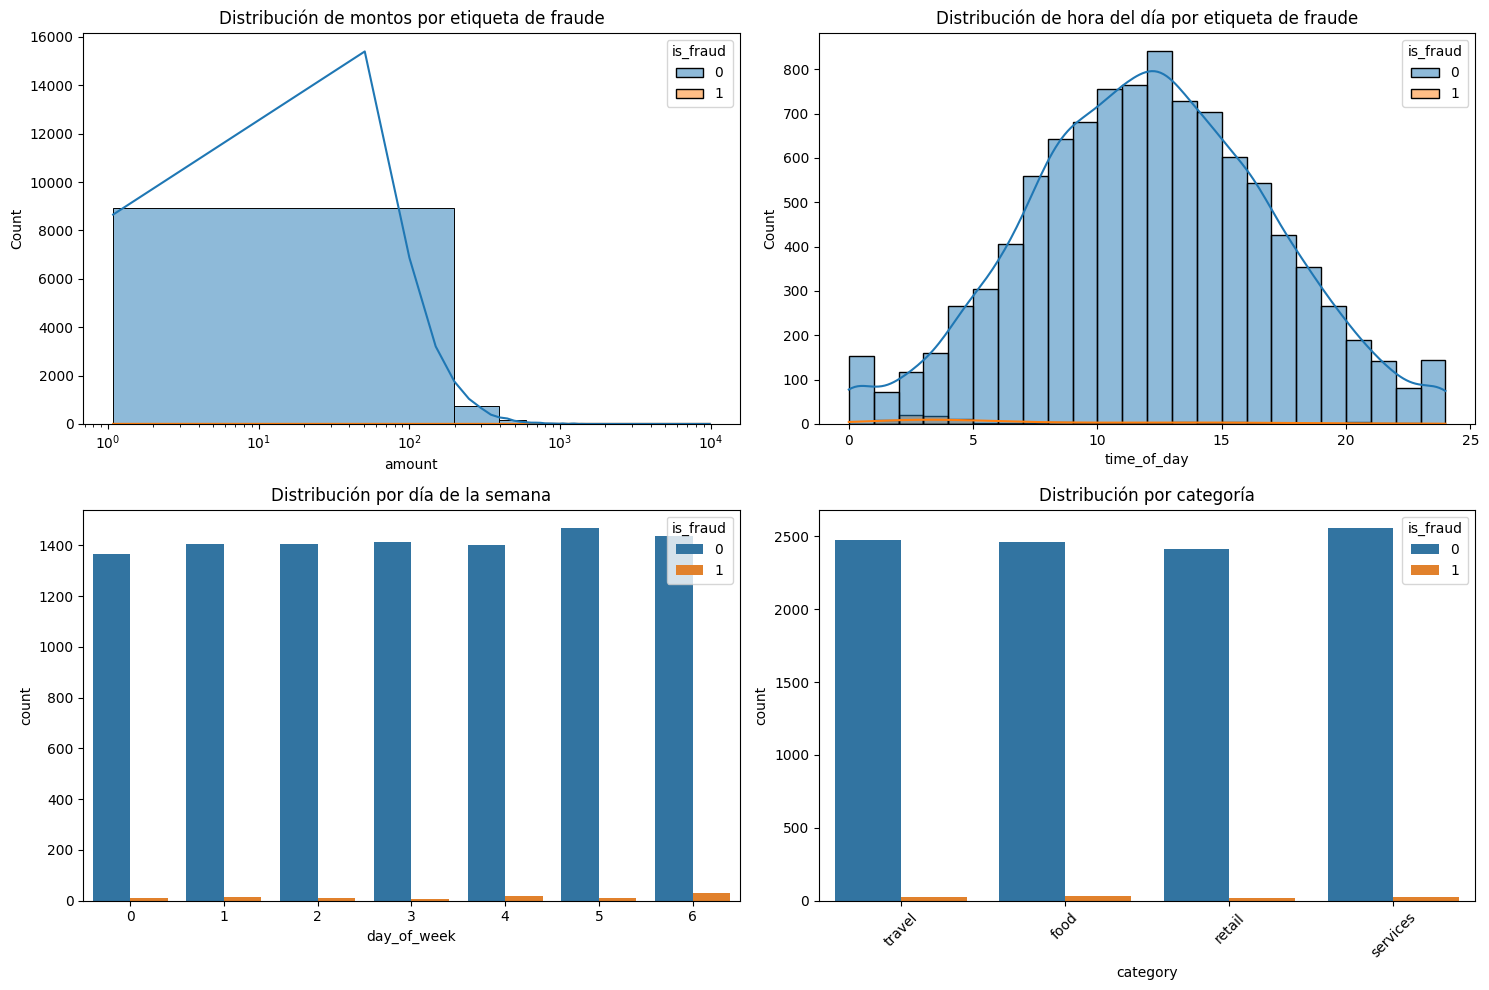

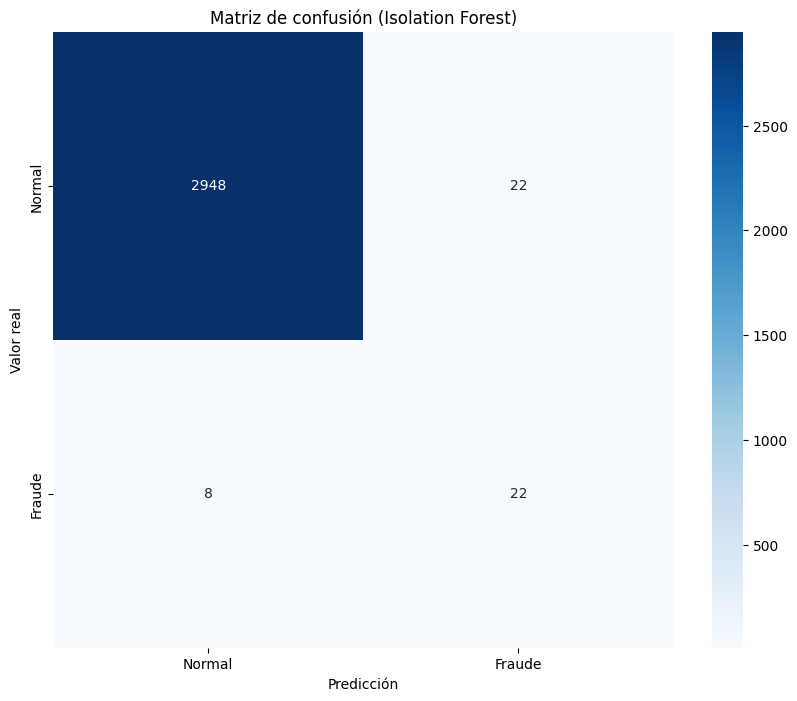

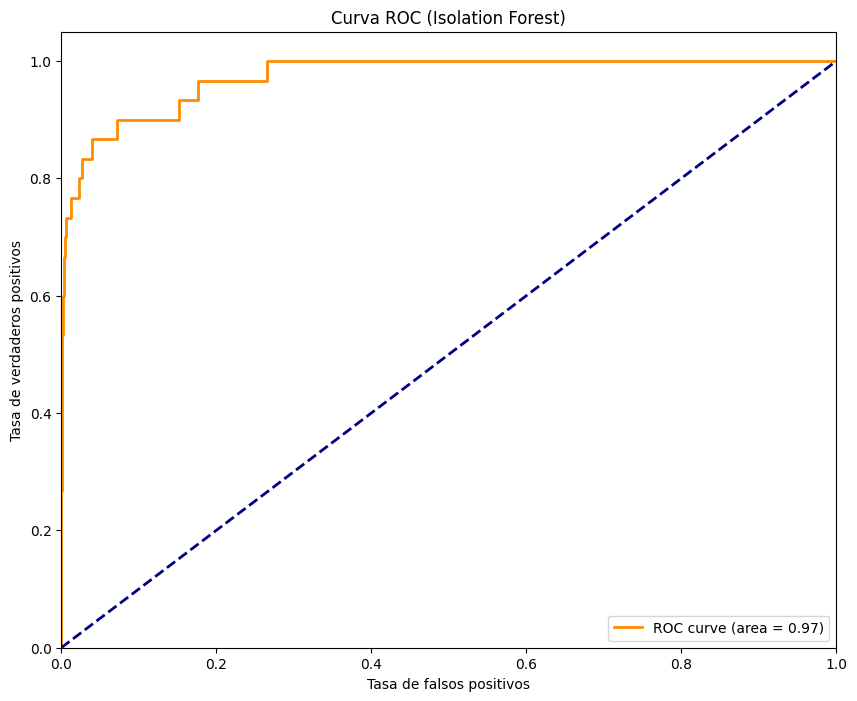

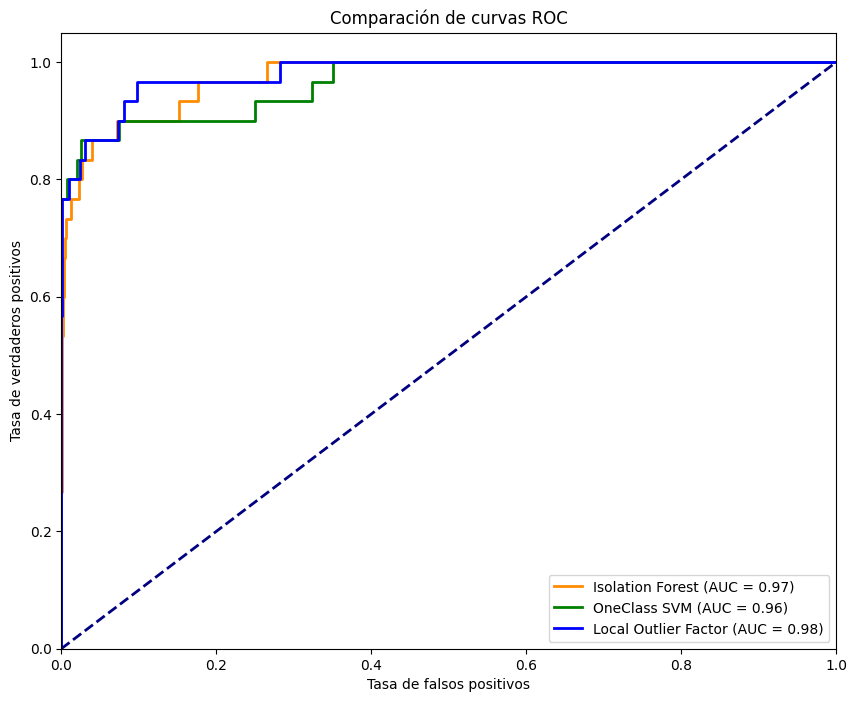

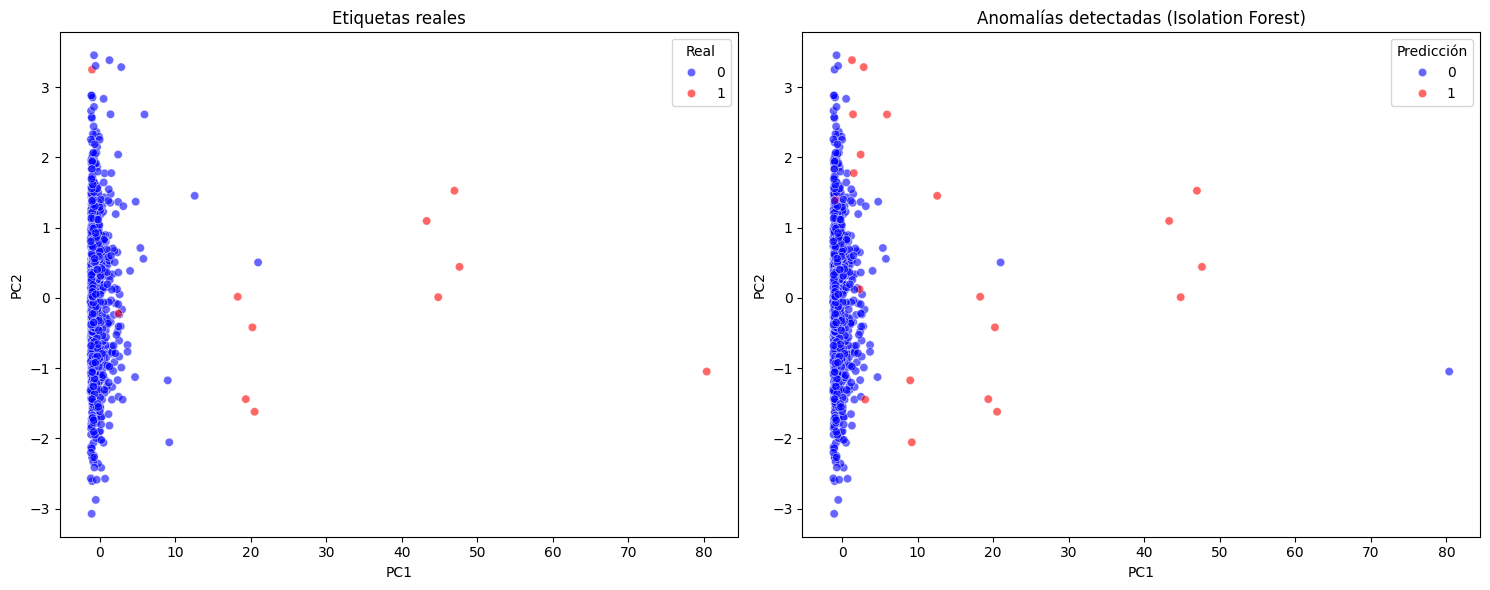

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar y explorar los datos
def load_sample_data():
    # Simulamos datos para este ejemplo
    np.random.seed(42)
    n_samples = 10000
    
    # Características normales
    amount = np.random.lognormal(mean=4.0, sigma=1.0, size=n_samples)
    time_of_day = np.random.normal(loc=12, scale=5, size=n_samples)
    day_of_week = np.random.randint(0, 7, size=n_samples)
    category = np.random.choice(['retail', 'services', 'food', 'travel'], size=n_samples)
    frequency = np.random.poisson(lam=5, size=n_samples)
    
    # Crear DataFrame
    df = pd.DataFrame({
        'amount': amount,
        'time_of_day': np.clip(time_of_day, 0, 24),
        'day_of_week': day_of_week,
        'category': category,
        'frequency_last_month': frequency
    })
    
    # Agregar algunas anomalías (aproximadamente 1% del dataset)
    n_anomalies = int(n_samples * 0.01)
    anomaly_idx = np.random.choice(range(n_samples), size=n_anomalies, replace=False)   
    
    # Diferentes tipos de anomalías
    for idx in anomaly_idx:
        anomaly_type = np.random.randint(0, 4)
        
        if anomaly_type == 0:
            # Monto muy alto
            df.loc[idx, 'amount'] = np.random.uniform(5000, 10000)
        elif anomaly_type == 1:
            # Horario inusual
            df.loc[idx, 'time_of_day'] = np.random.uniform(1, 4)
        elif anomaly_type == 2:
            # Combinación inusual de características
            df.loc[idx, 'amount'] = np.random.uniform(2000, 3000)
            df.loc[idx, 'time_of_day'] = np.random.uniform(2, 5)
            df.loc[idx, 'frequency_last_month'] = 0
        else:
            # Otra anomalía
            df.loc[idx, 'amount'] = np.random.uniform(4000, 6000)
            df.loc[idx, 'day_of_week'] = 6
    
    # Etiqueta real (solo para evaluación)
    df['is_fraud'] = 0
    df.loc[anomaly_idx, 'is_fraud'] = 1
    
    return df

# Cargar los datos
df = load_sample_data()

# 2. Exploración de datos
print("Información del dataset:")
print(f"Forma del dataset: {df.shape}")
print(f"Número de transacciones fraudulentas: {df['is_fraud'].sum()}")
print(f"Porcentaje de fraudes: {df['is_fraud'].mean() * 100:.2f}%")

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

# 3. Visualización de datos
plt.figure(figsize=(15, 10))

# Distribución de montos
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='amount', hue='is_fraud', bins=50, kde=True)
plt.title('Distribución de montos por etiqueta de fraude')
plt.xscale('log')

# Distribución de tiempo del día
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='time_of_day', hue='is_fraud', bins=24, kde=True)
plt.title('Distribución de hora del día por etiqueta de fraude')

# Distribución por día de la semana
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='day_of_week', hue='is_fraud')
plt.title('Distribución por día de la semana')

# Distribución por categoría
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='category', hue='is_fraud')
plt.title('Distribución por categoría')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('exploratory_analysis.png')

# 4. Preprocesamiento de datos
# Separar características y etiquetas
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Preprocesamiento: escalado numérico y codificación categórica
numeric_features = ['amount', 'time_of_day', 'day_of_week', 'frequency_last_month']
categorical_features = ['category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 5. Implementación del Isolation Forest
# Definir el pipeline
isolation_forest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('isolation_forest', IsolationForest(random_state=42, contamination=0.01))
])

# Entrenamiento (solo con datos no fraudulentos, simulando un escenario real)
# En un escenario real, no conoceríamos las etiquetas de fraude de antemano
X_train_normal = X_train[y_train == 0]
isolation_forest_pipeline.fit(X_train_normal)

# 6. Evaluación del modelo
# Predicción sobre el conjunto de prueba
# -1 indica anomalía, 1 indica normal
y_pred_isolation = isolation_forest_pipeline.predict(X_test)

# Convertir -1 a 1 y 1 a 0 para que 1 corresponda a fraude y 0 a normal
y_pred_isolation_binary = np.where(y_pred_isolation == -1, 1, 0)

# Calcular decisiones (score negativo para anomalías)
y_scores_isolation = -isolation_forest_pipeline.decision_function(X_test)

# Reporte de clasificación
print("\nReporte de clasificación (Isolation Forest):")
print(classification_report(y_test, y_pred_isolation_binary))

# Matriz de confusión
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_isolation_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión (Isolation Forest)')
plt.savefig('confusion_matrix.png')

# Curva ROC
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, y_scores_isolation)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC (Isolation Forest)')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png')

# 7. Optimización de hiperparámetros
# Definir el espacio de búsqueda
param_grid = {
    'isolation_forest__n_estimators': [50, 100, 200],
    'isolation_forest__max_samples': [100, 200, 'auto'],
    'isolation_forest__contamination': [0.005, 0.01, 0.02],
    'isolation_forest__max_features': [0.5, 0.75, 1.0]
}

# Configurar búsqueda de cuadrícula con puntuación personalizada para detección de anomalías
def custom_score(estimator, X):
    # Puntuación negativa para clasificación, más negativa = más anomalía
    scores = -estimator.decision_function(X)
    # Usar el AUC para evaluar la calidad
    fpr, tpr, _ = roc_curve(y_test, scores)
    return auc(fpr, tpr)

grid_search = GridSearchCV(
    isolation_forest_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring=custom_score,
    verbose=1,
    n_jobs=-1
)

# Ejecutar búsqueda de grid (esto puede tomar tiempo)
# Para ahorrar tiempo, podemos comentar esta sección y usar parámetros predeterminados
print("\nRealizando búsqueda de cuadrícula para optimizar hiperparámetros...")
# grid_search.fit(X_train, y_train)  # Comentado para ahorrar tiempo en la ejecución

# 8. Comparación con otros métodos de detección de anomalías
# OneClass SVM
oneclass_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('oneclass', OneClassSVM(nu=0.01, kernel="rbf", gamma='auto'))
])

# Entrenar con datos normales
oneclass_svm.fit(X_train_normal)

# Local Outlier Factor
lof = Pipeline([
    ('preprocessor', preprocessor),
    ('lof', LocalOutlierFactor(n_neighbors=20, contamination=0.01, novelty=True))
])

# Entrenar con datos normales
lof.fit(X_train_normal)

# Predicciones
y_pred_svm = oneclass_svm.predict(X_test)
y_pred_svm_binary = np.where(y_pred_svm == -1, 1, 0)

y_pred_lof = lof.predict(X_test)
y_pred_lof_binary = np.where(y_pred_lof == -1, 1, 0)

# Scores para ROC
y_scores_svm = -oneclass_svm.decision_function(X_test)
y_scores_lof = -lof.decision_function(X_test)

# Reportes de clasificación
print("\nReporte de clasificación (OneClass SVM):")
print(classification_report(y_test, y_pred_svm_binary))

print("\nReporte de clasificación (Local Outlier Factor):")
print(classification_report(y_test, y_pred_lof_binary))

# Comparación de curvas ROC
plt.figure(figsize=(10, 8))

# Isolation Forest
fpr_if, tpr_if, _ = roc_curve(y_test, y_scores_isolation)
roc_auc_if = auc(fpr_if, tpr_if)
plt.plot(fpr_if, tpr_if, color='darkorange', lw=2, label=f'Isolation Forest (AUC = {roc_auc_if:.2f})')

# OneClass SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_scores_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, color='green', lw=2, label=f'OneClass SVM (AUC = {roc_auc_svm:.2f})')

# Local Outlier Factor
fpr_lof, tpr_lof, _ = roc_curve(y_test, y_scores_lof)
roc_auc_lof = auc(fpr_lof, tpr_lof)
plt.plot(fpr_lof, tpr_lof, color='blue', lw=2, label=f'Local Outlier Factor (AUC = {roc_auc_lof:.2f})')

# Línea de referencia
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Comparación de curvas ROC')
plt.legend(loc="lower right")
plt.savefig('roc_comparison.png')

# 9. Visualización de anomalías detectadas
# Tomar una muestra para visualización
sample_size = 1000
X_sample = X_test.iloc[:sample_size]
y_sample = y_test.iloc[:sample_size]
y_pred_sample = y_pred_isolation_binary[:sample_size]

# Preparar datos para visualización
X_sample_processed = preprocessor.transform(X_sample)

# Reducción de dimensionalidad para visualización (2D)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_sample_2d = pca.fit_transform(X_sample_processed)

# Crear DataFrame para visualización
df_vis = pd.DataFrame({
    'PC1': X_sample_2d[:, 0],
    'PC2': X_sample_2d[:, 1],
    'Real': y_sample,
    'Predicción': y_pred_sample
})

# Visualización
plt.figure(figsize=(15, 6))

# Plot de etiquetas reales
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_vis, x='PC1', y='PC2', hue='Real', palette={0: 'blue', 1: 'red'}, alpha=0.6)
plt.title('Etiquetas reales')

# Plot de predicciones
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_vis, x='PC1', y='PC2', hue='Predicción', palette={0: 'blue', 1: 'red'}, alpha=0.6)
plt.title('Anomalías detectadas (Isolation Forest)')

plt.tight_layout()
plt.savefig('anomaly_visualization.png')

# 10. Evaluación de casos específicos
# Identificar falsos positivos y falsos negativos
fp_indices = np.where((y_test == 0) & (y_pred_isolation_binary == 1))[0]
fn_indices = np.where((y_test == 1) & (y_pred_isolation_binary == 0))[0]

# Mostrar algunos ejemplos
if len(fp_indices) > 0:
    print("\nEjemplos de falsos positivos (transacciones normales clasificadas como fraude):")
    print(X_test.iloc[fp_indices[:5]].reset_index(drop=True))

if len(fn_indices) > 0:
    print("\nEjemplos de falsos negativos (fraudes no detectados):")
    print(X_test.iloc[fn_indices[:5]].reset_index(drop=True))

# 11. Evaluación final y conclusiones
print("\nEvaluación final:")
print(f"Accuracy: {(y_pred_isolation_binary == y_test).mean():.4f}")
print(f"AUC (Isolation Forest): {roc_auc_if:.4f}")
print(f"AUC (OneClass SVM): {roc_auc_svm:.4f}")
print(f"AUC (Local Outlier Factor): {roc_auc_lof:.4f}")

print("\nConclusiones:")
print("- El modelo Isolation Forest logra detectar anomalías con un AUC de {:.2f}".format(roc_auc_if))
print("- Comparado con otros algoritmos como OneClass SVM y LOF, el rendimiento es {}".format(
    "superior" if roc_auc_if > max(roc_auc_svm, roc_auc_lof) else "inferior"
))
print("- Se recomienda {} para este tipo de detección de fraudes.".format(
    "Isolation Forest" if roc_auc_if > max(roc_auc_svm, roc_auc_lof) else 
    "OneClass SVM" if roc_auc_svm > roc_auc_lof else "Local Outlier Factor"
))

# Mostrar la importancia de las características (para Isolation Forest se puede aproximar)
feature_names = numeric_features + list(preprocessor.transformers_[1][1].get_feature_names_out(['category']))
